# Project imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from datetime import datetime
import time
from fontTools.merge.util import current_time
from Talpha import AdaptiveLayer

# initialize flappy game

In [2]:
import sys
import os
import pygame

os.environ['SDL_VIDEODRIVER'] = 'dummy'
os.environ['SDL_AUDIODRIVER'] = 'dummy'

sys.path.insert(0, '../itml-project2')
# noinspection PyUnresolvedReferences
from ple.games.flappybird import FlappyBird
# noinspection PyUnresolvedReferences
from ple import PLE

pygame 2.6.1 (SDL 2.28.4, Python 3.13.0)
Hello from the pygame community. https://www.pygame.org/contribute.html
couldn't import doomish


In [3]:
class PPO_Flappy(nn.Module):

    def __init__(self, hidden_layers, layer_configs=None, **adaptive_kwargs):
        super().__init__()
        sizes = [8] + hidden_layers
        self.hidden = nn.ModuleList([
            nn.Linear(sizes[i], sizes[i + 1]) for i in range(len(sizes) - 1)
        ])
        if layer_configs is not None:
            self.adaptive = nn.ModuleList([
                AdaptiveLayer(size, **cfg) for size, cfg in zip(hidden_layers, layer_configs)
            ])
        else:
            self.adaptive = nn.ModuleList([
                AdaptiveLayer(size, **adaptive_kwargs) for size in hidden_layers
            ])
        self.actor = nn.Linear(hidden_layers[-1], 2)
        self.critic = nn.Linear(hidden_layers[-1], 1)

    def forward(self, z):
        for linear, adaptive in zip(self.hidden, self.adaptive):
            z = adaptive(linear(z))
        action_prob = F.softmax(self.actor(z), dim=-1)
        state_value = self.critic(z)
        return action_prob, state_value

# Hyper parameters

In [4]:
lr = 0.0003
epochs = 2000
K_epochs = 5

epsilon = 0.2
gamma = 0.99
lam = 0.95
c0 = 1.0
c1 = 0.5
c2 = 0.01

# Adaptive Layer Params
w_init: [0] Ta(z), [1] Ta(z)*z², [2] Ta(z)*cos(z), [3] Ta(z)*abs(z), [4] Ta(z)*z

In [5]:
adap_l1 = [0.1, 0.1, 0.1, 0.6, 0.1]
adap_l2 = [0.1, 0.1, 0.1, 0.6, 0.1]
adap_l3 = [0.1, 0.1, 0.1, 0.6, 0.1]
adap_l4 = [0.1, 0.1, 0.1, 0.6, 0.1]
adap_l5 = [0.1, 0.1, 0.1, 0.6, 0.1]



a_hard1 = 200
a_soft1 = 2

a_hard23 = [200, 300]
a_soft23 = [1, 2]

layer_configs = [
    {'a': a_hard1,    'a_grad': a_soft1,    'w_init': adap_l1},
    {'a': a_hard23[0],'a_grad': a_soft23[0],'w_init': adap_l2},
    {'a': a_hard23[1],'a_grad': a_soft23[1],'w_init': adap_l3},
    {'a': a_hard1,    'a_grad': a_soft1,    'w_init': adap_l4},
    {'a': a_hard1,    'a_grad': a_soft1,    'w_init': adap_l5},
]

# Model initialization

In [6]:
model = PPO_Flappy([1024, 128, 16, 256, 256], layer_configs=layer_configs)

load = False

if load:
    try:
        model.load_state_dict(torch.load('Weights/Old/AT_L2.pt'))
    except FileNotFoundError:
        print("No weights found in: flappy weights/")
else:
    print("Training from scratch")

optimizer = torch.optim.Adam(model.parameters(),lr = lr)

Training from scratch


# Helper Functions

In [7]:
def normalize_game_state(state):
    means = torch.tensor([150.0, 0.0, 76.0, 108.0, 208.0, 226.0, 108.0, 208.0])
    stds = torch.tensor([44.0, 5.0, 44.0, 48.0, 48.0, 44.0, 48.0, 48.0])
    return (state - means) / stds


def get_Advantage(states, rewards):
    with torch.no_grad():
        _, prev_values = model(states)

    temp = torch.cat([prev_values, torch.zeros(1, 1)], dim=0)

    G = 0
    advantages = []
    t = len(rewards) - 1
    for _, reward in enumerate(reversed(rewards)):
        delta = reward + gamma * temp[t + 1] - temp[t]
        G = delta + lam * gamma * G
        advantages.insert(0, torch.FloatTensor([G]))
        t -= 1

    advantages = torch.stack(advantages)
    A = advantages.squeeze()

    returns = A + prev_values.squeeze()
    return A, returns


# training Loop

In [8]:
import time

print_freq = 20

start_time = time.time()
game = FlappyBird()

total_rewards = []
all_L_clip = []
all_L_vf = []
all_L_entropy = []

for i in range(epochs):
    done = False
    p = PLE(game, fps=30, display_screen=False, force_fps=True)
    p.init()

    # Block QUIT events so the headless dummy window can't trigger sys.exit()
    pygame.event.set_blocked(pygame.QUIT)

    log_probs = []
    values = []
    rewards = []
    states = []
    actions = []

    while not done:
        game_state = normalize_game_state(torch.tensor(list(p.getGameState().values())))
        action_prob, critic_val = model(game_state)

        # Actor Action
        action_prob = action_prob.detach().squeeze()
        dist = torch.distributions.Categorical(action_prob)
        action = dist.sample()

        # Critic State valuation
        critic_val = critic_val.detach().squeeze()

        if action == 0:
            ret_action = p.getActionSet()[0]
        else:
            ret_action = p.getActionSet()[1]

        # Acting on environment
        reward = p.act(ret_action)

        # Saving values
        log_probs.append(dist.log_prob(action))
        values.append(critic_val)
        rewards.append(reward)
        actions.append(action)
        states.append(game_state)

        if p.game_over():
            done = True
            p.reset_game()


    # Storing values after game loop
    total_rewards.append(sum(rewards))
    states = torch.stack(states).squeeze()
    values = torch.stack(values).squeeze()
    log_probs = torch.stack(log_probs).squeeze()
    actions = torch.stack(actions).squeeze()
    # Calculating advantage and storing returns for later
    A, returns = get_Advantage(states, rewards)


    for j in range(K_epochs):
        action_probs, new_values = model(states)
        new_dist = torch.distributions.Categorical(action_probs)
        new_policy = new_dist.log_prob(actions)

        ratio = torch.exp(new_policy - log_probs)
        clipped_ratio = torch.clamp(ratio, min=1 - epsilon, max=1 + epsilon)

        L_clip = (torch.min(ratio * A, clipped_ratio * A).mean()) * c0
        L_vf = ((new_values.squeeze() - returns.squeeze())**2) * c1
        entropy_bonus = (new_dist.entropy()) * c2

        loss = -(L_clip - L_vf + entropy_bonus).mean()

        all_L_clip.append(L_clip.mean().item())
        all_L_vf.append(L_vf.mean().item())
        all_L_entropy.append(entropy_bonus.mean().item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


    if (i + 1) % print_freq == 0:

        current_time = time.time()
        elapsed_time = current_time - start_time

        epoch_num = i + 1
        n_recent = int(K_epochs * print_freq)

        avg_reward = sum(total_rewards[-print_freq:]) / len(total_rewards[-print_freq:])
        L_clip_mean = sum(all_L_clip[-n_recent:]) / len(all_L_clip[-n_recent:])
        L_vf_mean = sum(all_L_vf[-n_recent:]) / len(all_L_vf[-n_recent:])
        L_entr_mean = sum(all_L_entropy[-n_recent:]) / len(all_L_entropy[-n_recent:])

        print(f"Epoch: {epoch_num}, "
              f"clip L: {L_clip_mean:.4f}, "
              f"SE L: {L_vf_mean:.4f}, "
              f"Entr L: {L_entr_mean:.4f}, "
              f"Avg Pipes: {avg_reward:.4f}, "
              f"Time: {elapsed_time:.4f}s")

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


Epoch: 20, clip L: -0.2982, SE L: 0.3079, Entr L: 0.0066, Avg Pipes: -5.0000, Time: 1.1412s
Epoch: 40, clip L: -0.0186, SE L: 0.0105, Entr L: 0.0069, Avg Pipes: -5.0000, Time: 2.1030s
Epoch: 60, clip L: 0.0081, SE L: 0.0092, Entr L: 0.0053, Avg Pipes: -5.0000, Time: 3.1817s
Epoch: 80, clip L: -0.0094, SE L: 0.0062, Entr L: 0.0063, Avg Pipes: -5.0000, Time: 4.1699s
Epoch: 100, clip L: 0.0224, SE L: 0.0122, Entr L: 0.0067, Avg Pipes: -5.0000, Time: 5.1615s
Epoch: 120, clip L: 0.0009, SE L: 0.0091, Entr L: 0.0067, Avg Pipes: -5.0000, Time: 6.1388s
Epoch: 140, clip L: 0.0095, SE L: 0.0048, Entr L: 0.0066, Avg Pipes: -5.0000, Time: 7.1687s
Epoch: 160, clip L: -0.0064, SE L: 0.0067, Entr L: 0.0057, Avg Pipes: -5.0000, Time: 8.2003s
Epoch: 180, clip L: 0.0057, SE L: 0.0026, Entr L: 0.0041, Avg Pipes: -5.0000, Time: 9.2491s
Epoch: 200, clip L: -0.0009, SE L: 0.0046, Entr L: 0.0059, Avg Pipes: -5.0000, Time: 10.2907s
Epoch: 220, clip L: -0.0033, SE L: 0.0068, Entr L: 0.0040, Avg Pipes: -5.0000,

KeyboardInterrupt: 

# Plotting Stats

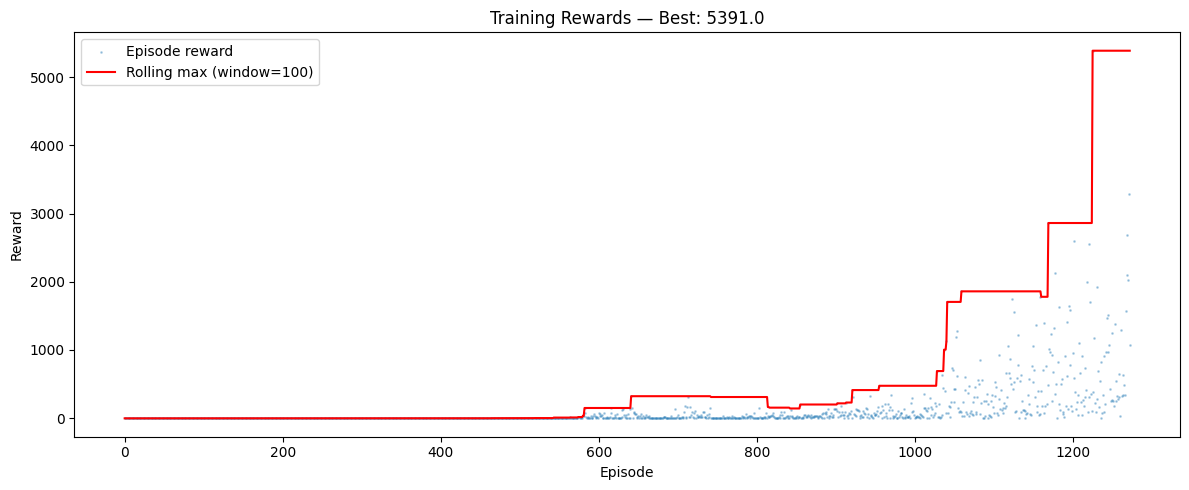

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(range(len(total_rewards)), total_rewards, s=1, alpha=0.3, label='Episode reward')

# Rolling max reward
window = 100
if len(total_rewards) >= window:
    rolling_max = [max(total_rewards[max(0,i-window):i+1]) for i in range(len(total_rewards))]
    ax.plot(rolling_max, color='red', linewidth=1.5, label=f'Rolling max (window={window})')

ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
ax.set_title(f'Training Rewards — Best: {max(total_rewards):.1f}')
ax.legend()
plt.tight_layout()
plt.show()


# Saving Model

In [11]:
torch.save(model.state_dict(), "Weights/AT_L5Max.pt")